In [1]:
# change to the root directory of the project
import os
if os.getcwd().split("/")[-1] == "examples":
    os.chdir('..')
    
import matplotlib.pyplot as plt
from matplotlib import cm
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import scipy
from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
aln = ALNModel()
aln.params['duration'] = 100.
aln.params.signalV = 0.
aln.params.de = 0.
aln.params.di = 0.
len_time = int(round(aln.params.duration/aln.params.dt,1)+1)

aln.params.mue_ext_mean = 0.
aln.params.mui_ext_mean = 0.

aln.run()

#print(aln['rates_exc'].shape, aln['rates_exc'])

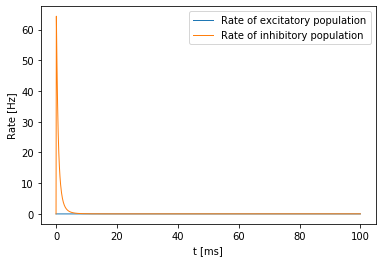

In [3]:
plt.plot(aln['t'], aln['rates_exc'].T, lw=1, label = "Rate of excitatory population")
plt.plot(aln['t'], aln['rates_inh'].T, lw=1, label = "Rate of inhibitory population")
plt.xlabel("t [ms]")
plt.ylabel("Rate [Hz]")
plt.legend(loc='upper right')
#plt.xlim(1000, 2000)
plt.show()

In [4]:
# plot uncontrolled dynamics, controlled dynamics
def plot_control(control_, target_ = aln.getZeroTarget()):
    
    # no control
    aln.run()
    output_vars = aln.output_vars
    control_vars = aln.control_input_vars

    fig, ax = plt.subplots(3, 3, figsize=(18, 12))
    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=0.3)

    ax[0,0].plot(aln.t, aln[output_vars[0]][0,:])
    ax[0,0].set(xlabel='t [ms]', ylabel=output_vars[0])
    ax[0,1].plot(aln.t, aln[output_vars[1]][0,:])
    ax[0,1].set(xlabel='t [ms]', ylabel=output_vars[1])
    ax[0,2].plot(aln.t, aln[output_vars[2]][0,:])
    ax[0,2].set(xlabel='t [ms]', ylabel=output_vars[2])
    
    aln.run(control=control_)

    ax[1,0].plot(aln.t, aln[output_vars[0]][0,:])
    ax[1,0].set(xlabel='t [ms]', ylabel=output_vars[0])
    ax[1,1].plot(aln.t, aln[output_vars[1]][0,:])
    ax[1,1].set(xlabel='t [ms]', ylabel=output_vars[1])
    ax[1,2].plot(aln.t, aln[output_vars[2]][0,:])
    ax[1,2].set(xlabel='t [ms]', ylabel=output_vars[2])
    
    ax[2,0].plot(aln.t, control_[0,0,:])
    ax[2,0].set(xlabel='t [ms]', ylabel=str(control_vars[0] + ' control'))
    ax[2,1].plot(aln.t, control_[0,1,:])
    ax[2,1].set(xlabel='t [ms]', ylabel=str(control_vars[1] + ' control'))
    
    if (target.any() != 0.):
        ax[0,0].plot(aln.t, target[0,0,:])
        ax[1,0].plot(aln.t, target[0,0,:])
        ax[0,1].plot(aln.t, target[0,1,:])
        ax[1,1].plot(aln.t, target[0,1,:])
        
        state = aln.getZeroState()
        for i in range(len(output_vars)):
            state[:,i,:] = aln[output_vars[i]][:,:]
        cost = aln.cost(state, target_, control_)
        
        ax[2,2].plot(aln.t, cost)
        ax[2,2].set(xlabel='t [ms]', ylabel='cost')
    
    
    plt.savefig('control_aln.png')
    
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:,i_time] = maxI_
    return control_

### Exploration of parameter space

Bifurcation parameters are external currents of excitatory and inhibitory population.


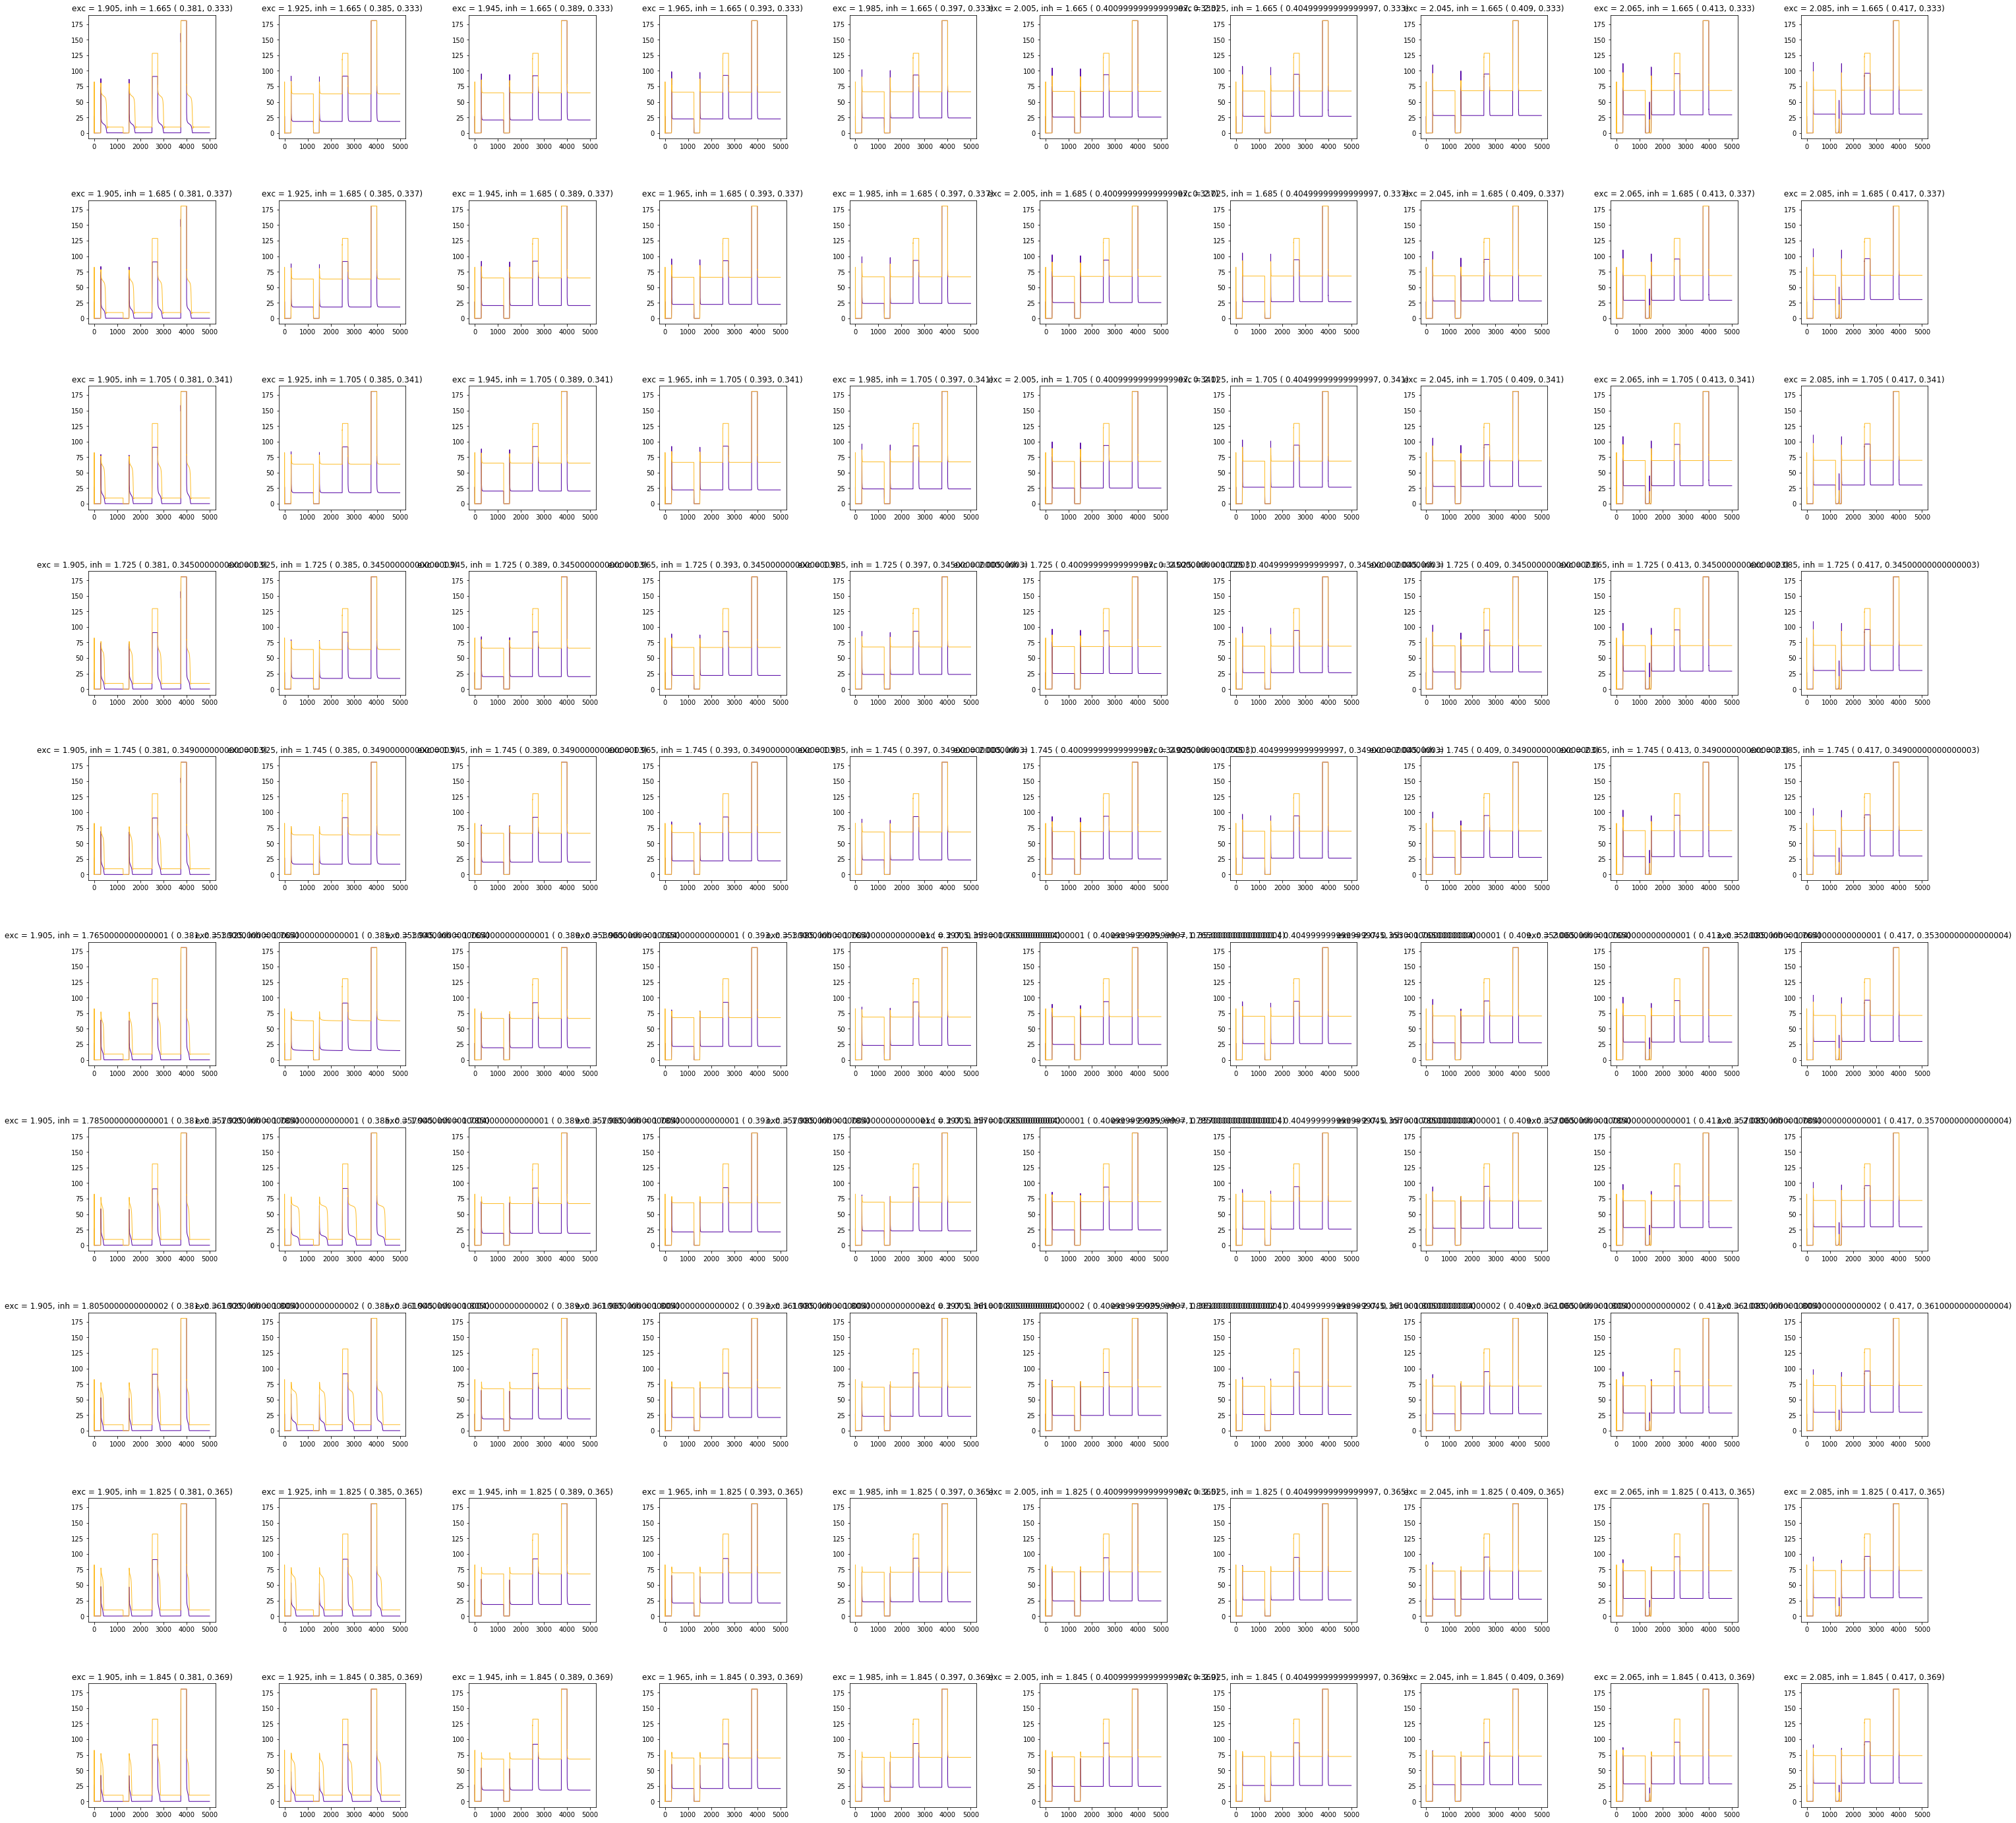

In [5]:
aln = ALNModel()
aln.params['duration'] = 5. * 1000.
#aln.params.signalV = 0.
#aln.params.de = 0.
#aln.params.di = 0.
len_time = int(round(aln.params.duration/aln.params.dt,1)+1)
control0 = aln.getZeroControl()

for i in range(int(0.0*len_time), int(0.05*len_time), 1):
    control0[0,:,i] = -6.
for i in range(int(0.25*len_time), int(0.3*len_time), 1):
    control0[0,:,i] = -2.
for i in range(int(0.5*len_time), int(0.55*len_time), 1):
    control0[0,:,i] = 2.    
for i in range(int(0.75*len_time), int(0.8*len_time), 1):
    control0[0,:,i] = 6. 

# NO ADAPTATION
aln.params.IA_init = np.array([0.])

aln.params.mue_ext_mean = 0.0 # increasing current to excitatory in rows
aln.params.mui_ext_mean = 0.0 # increasing current to inhibitory in columns

incr = 10
fig,ax = plt.subplots(incr, incr, figsize=(50, 50))
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.5, hspace=0.5)

starte = 1.905
starti = 1.665
step = 0.02
for i in range(incr):
    for j in range(incr):
        # exc 2.05
        # inh 1.7
        exc_current = starte + (j * step)
        inh_current = starti + (i * step)
        aln.params.ext_exc_current = exc_current # increasing current to excitatory in rows
        aln.params.ext_inh_current = inh_current # increasing current to inhibitory in columns
        aln.run(control = control0)
    
        ax[i,j].set_title(str('exc = ' + str(exc_current) + ', inh = ' + str(inh_current) + ' ( ' + str(exc_current/5.)
                              + ', ' +  str(inh_current/5.) + ')'))
        ax[i,j].plot(aln['t'], aln['rates_exc'].T, lw=1, c=cpalette[0], label = "Rate of excitatory population")
        ax[i,j].plot(aln['t'], aln['rates_inh'].T, lw=1, c=cpalette[-1], label = "Rate of inhibitory population")
        #ax[i,j].set_ylabel("Rate [Hz]")
        #ax[i,j].set_xlabel("t [ms]")
        #ax[i,j].legend(loc='upper center', bbox_to_anchor=(0.5, 1.2), shadow=True, ncol=1)

        #ax2 = ax[i,j].twinx()
        #ax2.plot(aln['t'], control0[0,0,:], lw=1, c=cpalette[1], label = "Control exc")
        #ax2.plot(aln['t'], control0[0,0,:], lw=1, c=cpalette[1], label = "Control inh")
        #ax2.plot(aln['t'], aln['IA'].T, lw=1, c=cpalette[1], label = "Adaptation current")
        #ax2.plot(aln['t'], control0[0,0,:], lw=1, c=cpalette[-2], linestyle="dashed", label = "Control: External current (exc)")

        #ax2.set_ylabel("Adaptation and input current (exc)")
        #ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), shadow=True, ncol=1)
        
#plt.xlim(1000, 2000)
plt.savefig('parameter_space.png')

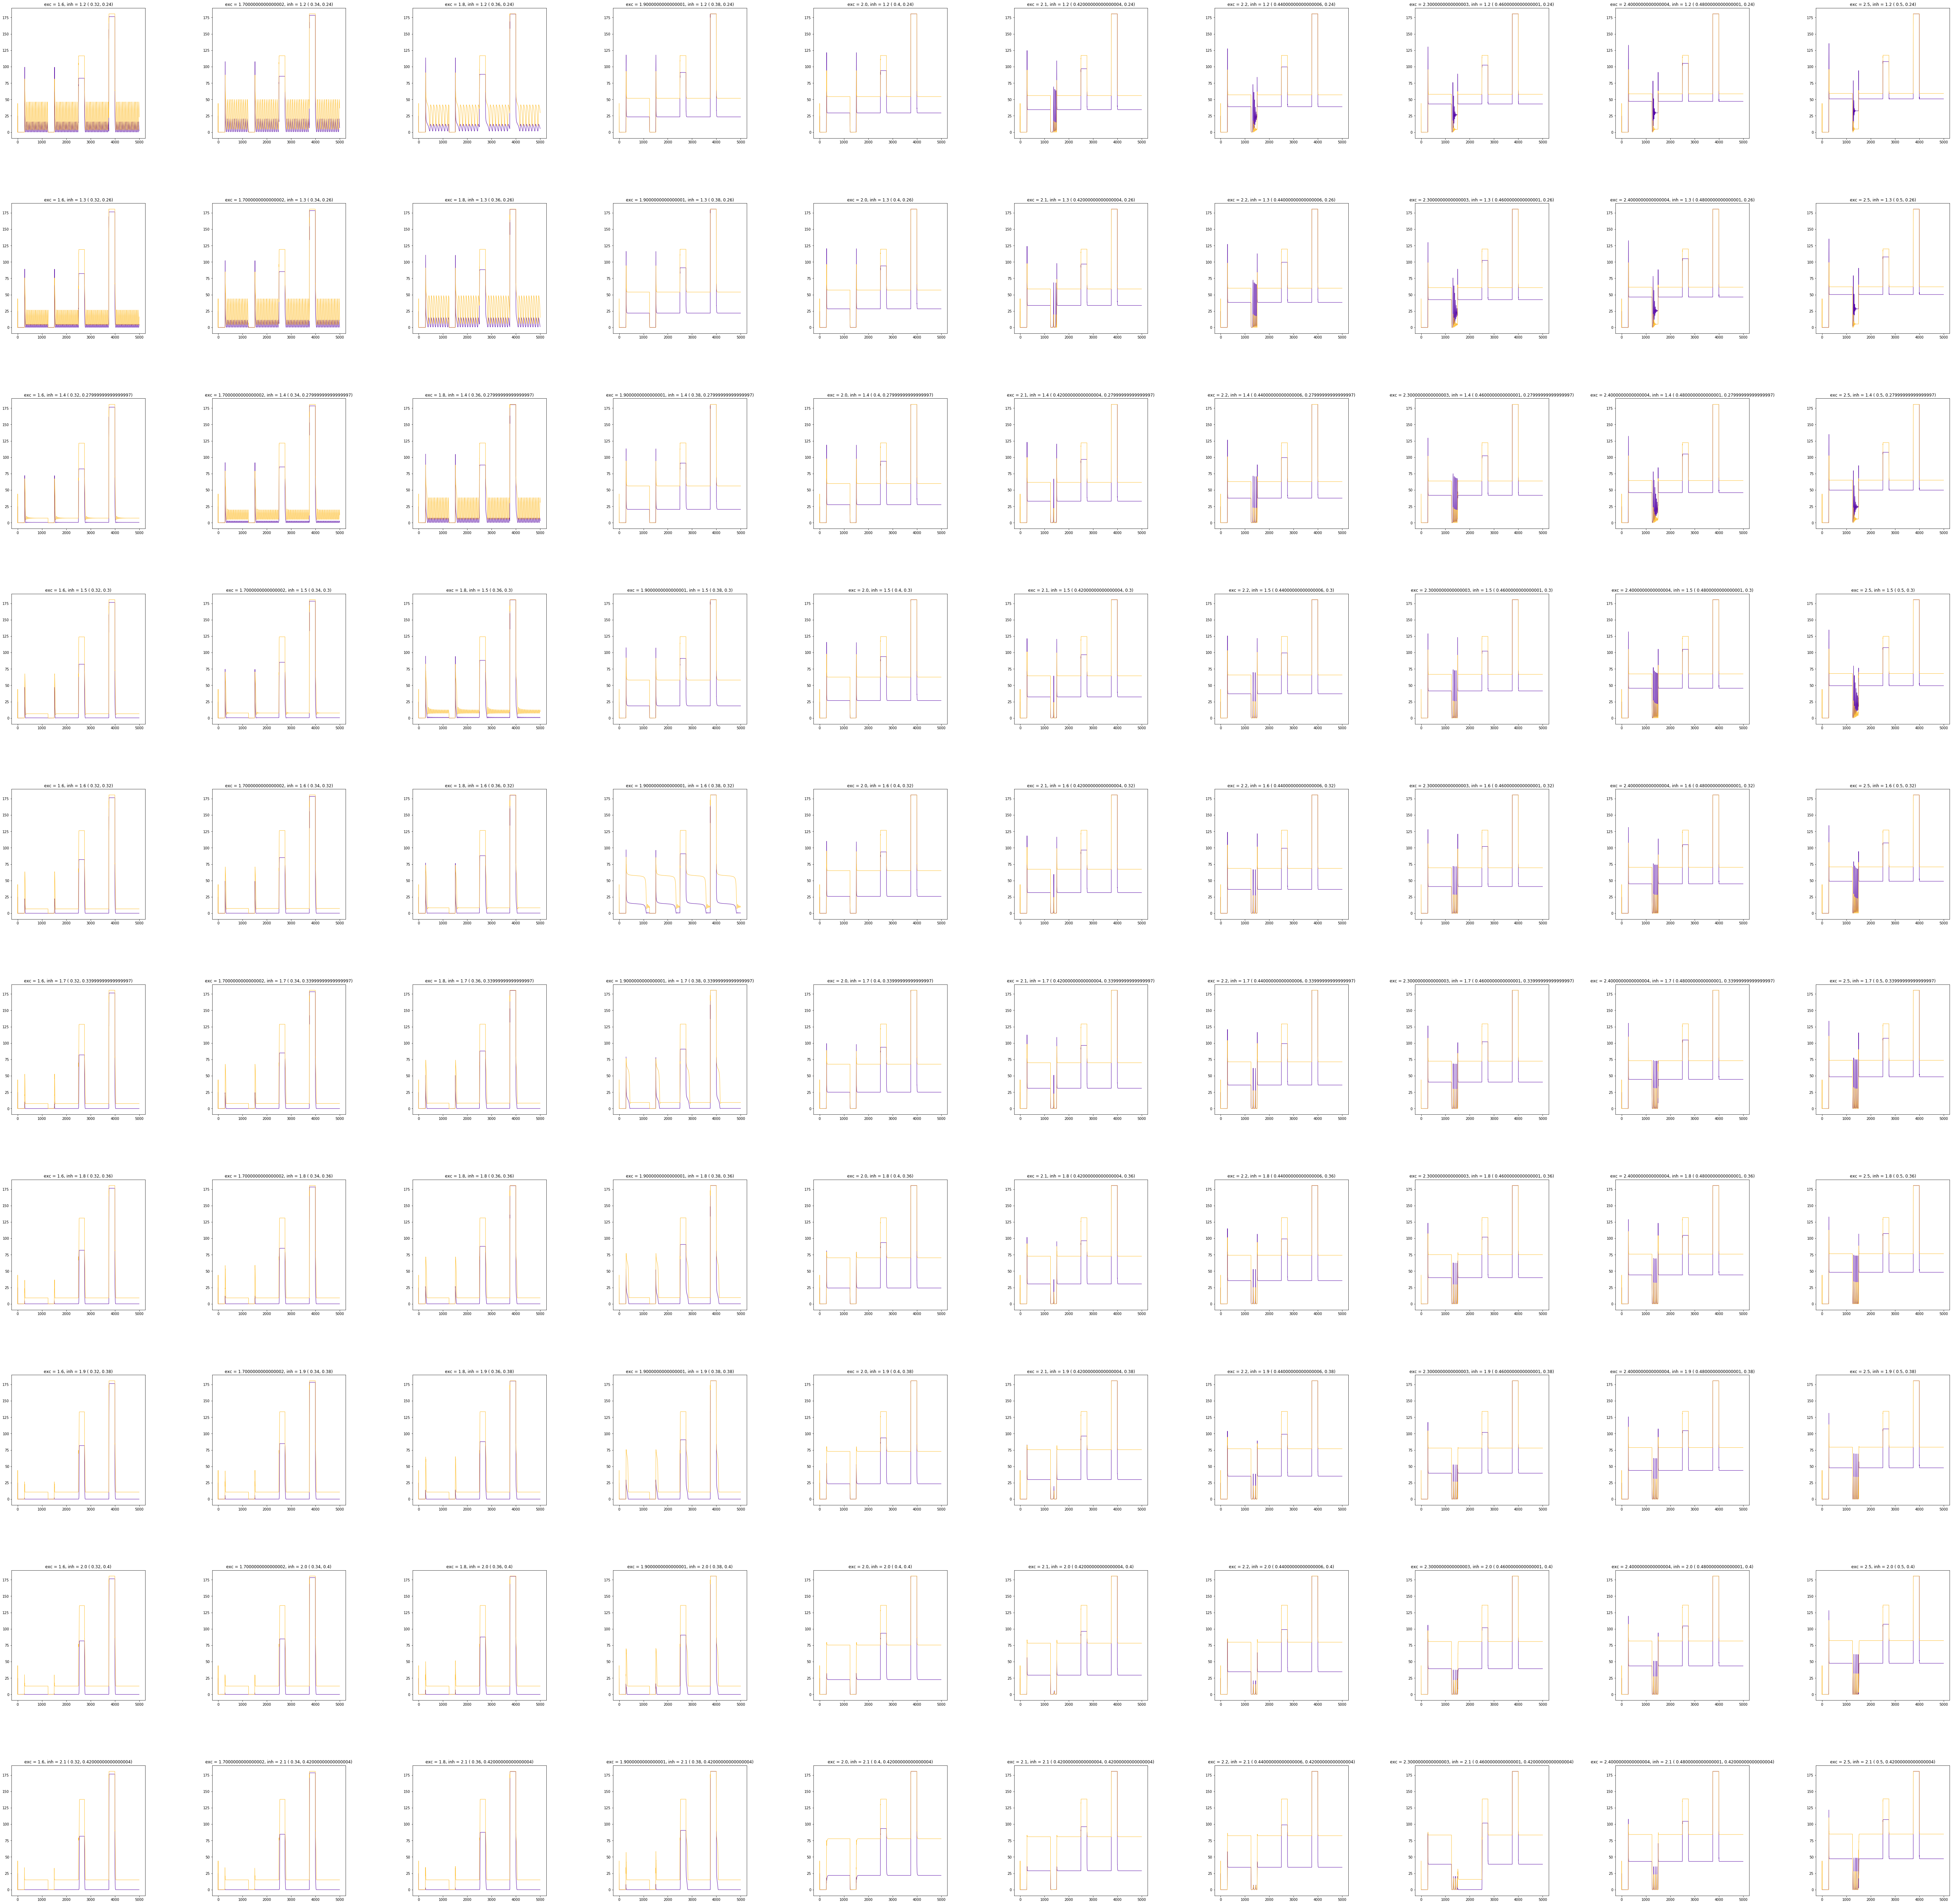

In [254]:
incr = 10
fig,ax = plt.subplots(incr, incr, figsize=(100, 100))
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.5, hspace=0.5)

starte = 1.6
starti = 1.2
step = 0.1
for i in range(10):
    for j in range(10):
        exc_current = starte + (j * step)
        inh_current = starti + (i * step)
        aln.params.ext_exc_current = exc_current # increasing current to excitatory in rows
        aln.params.ext_inh_current = inh_current # increasing current to inhibitory in columns
        aln.run(control = control0)
    
        ax[i,j].set_title(str('exc = ' + str(exc_current) + ', inh = ' + str(inh_current) 
                              + ' ( ' + str(exc_current/5.) + ', ' +  str(inh_current/5.) + ')'))
        ax[i,j].plot(aln['t'], aln['rates_exc'].T, lw=1, c=cpalette[0], label = "Rate of excitatory population")
        ax[i,j].plot(aln['t'], aln['rates_inh'].T, lw=1, c=cpalette[-1], label = "Rate of inhibitory population")
        #ax[i,j].set_ylabel("Rate [Hz]")
        #ax[i,j].set_xlabel("t [ms]")
        #ax[i,j].legend(loc='upper center', bbox_to_anchor=(0.5, 1.2), shadow=True, ncol=1)

        #ax2 = ax[i,j].twinx()
        #ax2.plot(aln['t'], control0[0,0,:], lw=1, c=cpalette[1], label = "Control exc")
        #ax2.plot(aln['t'], control0[0,0,:], lw=1, c=cpalette[1], label = "Control inh")
        #ax2.plot(aln['t'], aln['IA'].T, lw=1, c=cpalette[1], label = "Adaptation current")
        #ax2.plot(aln['t'], control0[0,0,:], lw=1, c=cpalette[-2], linestyle="dashed", label = "Control: External current (exc)")

        #ax2.set_ylabel("Adaptation and input current (exc)")
        #ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), shadow=True, ncol=1)
        
#plt.xlim(1000, 2000)
plt.savefig('parameter_space1.png')

### Bistability

[1.3109e-03 3.7674e+01]


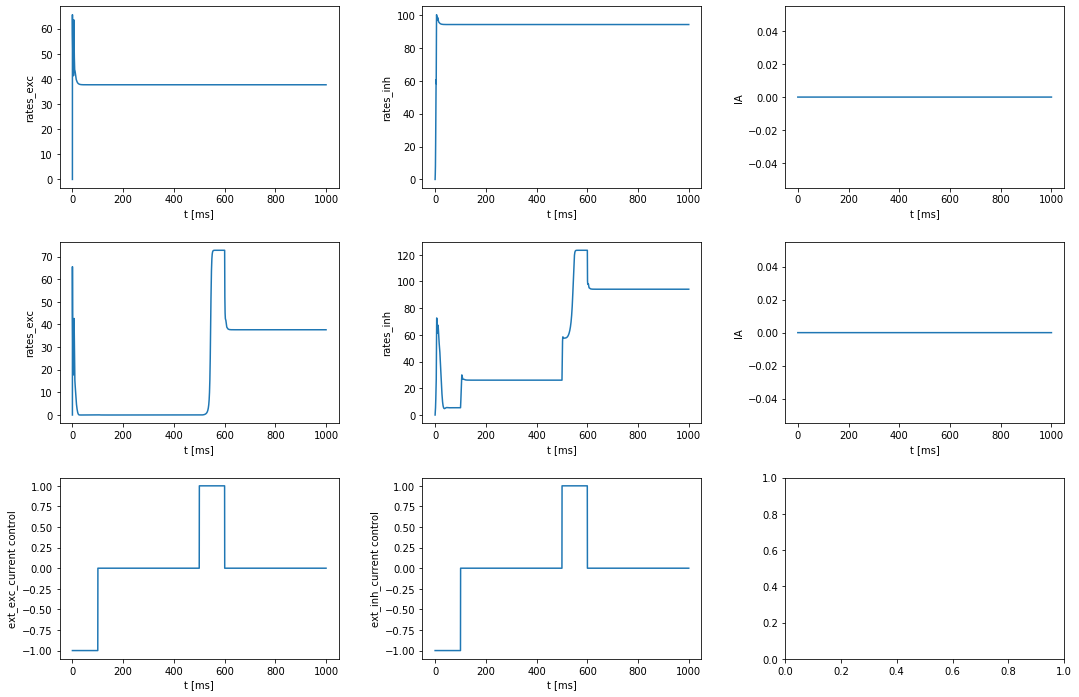

In [6]:
aln = ALNModel()

aln.params['duration'] = 1000.

control0 = aln.getZeroControl()
target = aln.getZeroTarget()
control0 = step_control(maxI_ = 1.)

aln.params.ext_exc_current = 2.3 # increasing current to excitatory in rows
aln.params.ext_inh_current = 2.5 # increasing current to inhibitory in columns

# NO ADAPTATION
aln.params.IA_init = np.array([0.])

aln.params.mue_ext_mean = 0.0 # increasing current to excitatory in rows
aln.params.mui_ext_mean = 0.0 # increasing current to inhibitory in columns

state = aln.getZeroState()
aln.run(control = control0)

output = aln.output_vars

for i in range(len(output)):
    state[:,i,:] = aln[output[i]][:,:]
    
steady_rates = np.zeros((2))
steady_rates[0] = np.mean(state[0,0,1000:5000])
steady_rates[1] = np.mean(state[0,0,6500:])

print(steady_rates)

plot_control(control0)

### State switching task in bistability regime: Switch from high to low state

In [164]:
aln = ALNModel()

aln.params.signalV = 0.
aln.params.de = 0.
aln.params.di = 0.

aln.params.duration = 100.
cost.setParams(1.0, 0.0, 0.)

# NO ADAPTATION
aln.params.IA_init = np.array([0.])

aln.params.mue_ext_mean = 0.0 # increasing current to excitatory in rows
aln.params.mui_ext_mean = 0.0 # increasing current to inhibitory in columns

control0 = aln.getZeroControl()


# set excitatory rates as target

target = aln.getZeroTarget()
target[:,0,:] = steady_rates[0]
target[:,1,:] = steady_rates[1]

step_size = 0.5

for init in aln.init_vars:
    aln.params[init] = np.zeros(aln.params[init].shape)
    
aln.params.ext_exc_current = 2.3 # increasing current to excitatory in rows
aln.params.ext_inh_current = 2.5 # increasing current to inhibitory in columns

state = aln.getZeroState()
aln.run()
output = aln.output_vars

for i in range(len(output)):
    state[:,i,:] = aln[output[i]]

A2_bestControl, A2_bestState, A2_cost, A2_runtime = aln.A2(control0, target, max_iteration_ = 3, tolerance_ = 1e-12,
                include_timestep_ = 1000, start_step_ = 1000., test_step_ = 1e-6, max_control_ = 2000.)

set cost params
RUN  0 , total integrated cost:  221753.44980405498
RUN  1 , total integrated cost:  5256.106631936945
RUN  2 , total integrated cost:  3619.437022655536
RUN  3 , total integrated cost:  3379.279599478544
Improved over  3  iterations by  99  percent.


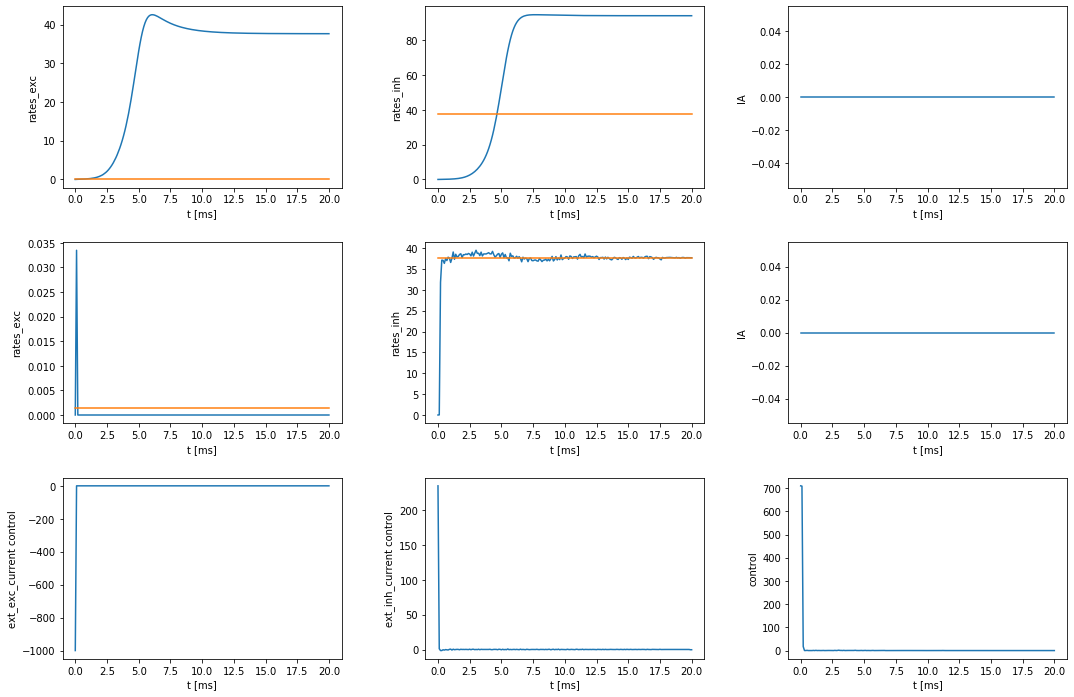

In [160]:
plot_control(A2_bestControl, target)

### Force into other rhythm in oscillatory regime

Externat current: exc =  0.4 , inh =  0.0


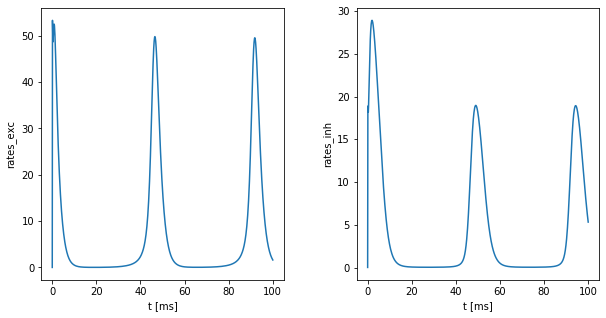

-------------------------------------------
Externat current: exc =  0.7 , inh =  0.0


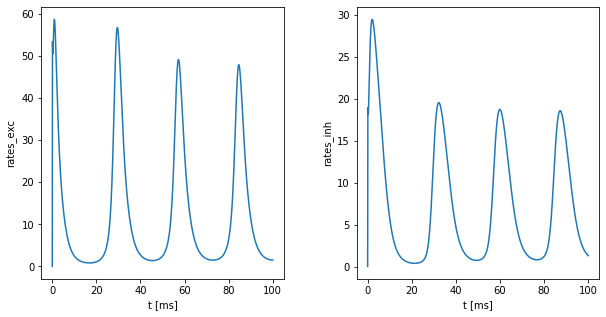

-------------------------------------------


In [294]:
aln = ALNModel()

aln.params['duration'] = 100.
aln.params.signalV = 0.
aln.params.de = 0.
aln.params.di = 0.

control0 = aln.getZeroControl()

aln.params.ext_exc_current = 0.4 # increasing current to excitatory in rows
aln.params.ext_inh_current = 0.0 # increasing current to inhibitory in columns
# NO ADAPTATION
aln.params.IA_init = np.array([0.])
aln.params.mue_ext_mean = 0.0 # increasing current to excitatory in rows
aln.params.mui_ext_mean = 0.0 # increasing current to inhibitory in columns

output = aln.output_vars
aln.run()

print("Externat current: exc = ", aln.params.ext_exc_current, ", inh = ", aln.params.ext_inh_current)
fig, ax = plt.subplots(1, 2 , figsize=(10, 5))
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=0.3)
for i in range(2):
    ax[i].plot(aln.t, aln[output[i]][0,:] )
    ax[i].set(xlabel='t [ms]', ylabel=output[i])
plt.show()
print("-------------------------------------------")

# set this excitatory rate as target
target = aln.getZeroTarget()
target[:,0,:] = aln[output[0]]
target[:,1,:] = aln[output[1]]

aln.params.ext_exc_current = 0.7 # increasing current to excitatory in rows
aln.run()

print("Externat current: exc = ", aln.params.ext_exc_current, ", inh = ", aln.params.ext_inh_current)
fig, ax = plt.subplots(1, 2 , figsize=(10, 5))
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=0.3)
for i in range(2):
    ax[i].plot(aln.t, aln[output[i]][0,:] )
    ax[i].set(xlabel='t [ms]', ylabel=output[i])
plt.show()
print("-------------------------------------------")

In [295]:
state = aln.getZeroState()
aln.run()
output = aln.output_vars

for i in range(len(output)):
    state[:,i,:] = aln[output[i]]

A2_bestControl, A2_bestState, A2_cost, A2_runtime = aln.A2(control0, target, max_iteration_ = 10, tolerance_ = 1e-12,
                include_timestep_ = 30, start_step_ = 10., test_step_ = 1e-6, max_control_ = 100.)

RUN  0 , total integrated cost:  25396.94603275548
RUN  1 , total integrated cost:  100.21696156892875
RUN  2 , total integrated cost:  29.82309836123171
RUN  3 , total integrated cost:  9.075576559785903
RUN  4 , total integrated cost:  5.541428712203885
RUN  5 , total integrated cost:  5.119741965905126
RUN  6 , total integrated cost:  4.44519695983855
RUN  7 , total integrated cost:  3.8358851549855646
RUN  8 , total integrated cost:  3.8246442759270725
RUN  9 , total integrated cost:  4.363403752708163
RUN  10 , total integrated cost:  5.284237492637835
Improved over  10  iterations by  100  percent.


In [300]:
A2_bestControl1, A2_bestState1, A2_cost1, A2_runtime1 = aln.A2(A2_bestControl, target, max_iteration_ = 1, tolerance_ = 1e-12,
                include_timestep_ = 1000, start_step_ = 1000., test_step_ = 1e-6, max_control_ = 100.)

RUN  0 , total integrated cost:  5.284237492637835
RUN  1 , total integrated cost:  5.221163768412439
Improved over  1  iterations by  2  percent.


In [301]:
control1 = control0.copy()
control1[0,0,:] = -0.3

A2_bestControl2, A2_bestState2, A2_cost2, A2_runtime2 = aln.A2(control1, target, max_iteration_ = 2, tolerance_ = 1e-12,
                include_timestep_ = 10, start_step_ = 10., test_step_ = 1e-6, max_control_ = 100.)

RUN  0 , total integrated cost:  1.1065512502777602e-26
Control only changes marginally.
Improved over  0  iterations by  0  percent.


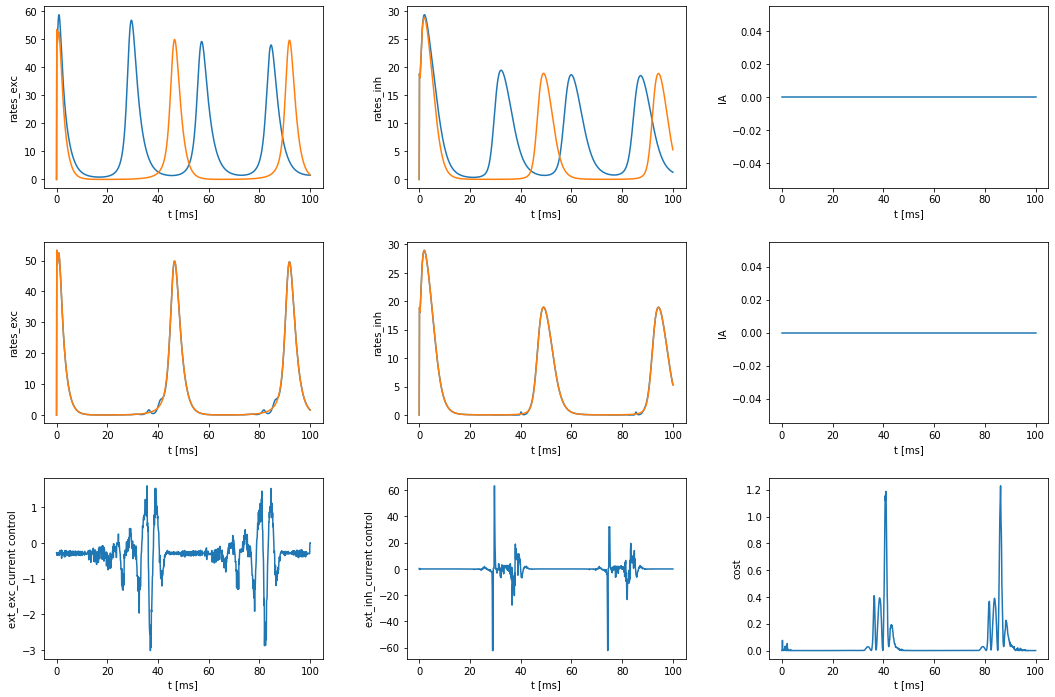

In [299]:
plot_control(A2_bestControl1, target)

### 2-node network

starting rate =  [0. 0. 0.]
External current: exc =  2.3 , inh =  2.5


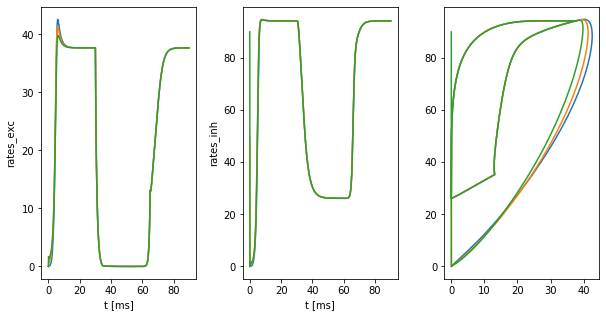

-------------------------------------------


'\n# set this excitatory rate as target\ntarget = aln.getZeroTarget()\ntarget[:,0,:] = aln[output[0]]\ntarget[:,1,:] = aln[output[1]]\n\naln.params.ext_exc_current = 0.7\naln.run()\n\nprint("External current: exc = ", aln.params.ext_exc_current, ", inh = ", aln.params.ext_inh_current)\nfig, ax = plt.subplots(1, 2 , figsize=(10, 5))\nplt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=0.3)\nfor i in range(2):\n    for n in range(aln.params.N):\n        ax[i].plot(aln.t, aln[output[i]][n,:] )\n    ax[i].set(xlabel=\'t [ms]\', ylabel=output[i])\nplt.show()\nprint("-------------------------------------------")\n'

In [7]:
aln = ALNModel()
output = aln.output_vars

c_mat = np.array([[0, 0, 0], [0, 0, 0], [0, 0, 0]])
c_scheme = np.zeros((len(output), len(output) ))
c_scheme[0,0] = 0.

fiber_matrix = np.zeros((len(c_mat), len(c_mat)))

aln = ALNModel(Cmat = c_mat, Dmat = fiber_matrix)

u_mat = np.identity(aln.params['N'])
u_scheme = np.array([[1, 0], [0, 0]])

aln.params['duration'] = 90.

control0 = aln.getZeroControl()
control0[:,0,300:350] = -2.
control0[:,0,600:650] = 3.

aln.params.signalV = 0.
aln.params.de = 0.
aln.params.di = 0.

for init in aln.init_vars:
    aln.params[init] = np.zeros(aln.params[init].shape)

aln.params.ext_exc_current = 2.3
aln.params.ext_inh_current = 2.5
aln.params.mue_ext_mean = 0.0
aln.params.mui_ext_mean = 0.0

aln.params.rates_exc_init = np.array([0., 0., 0.])
aln.params.rates_inh_init = np.array([0., 50., 90.])

aln.run(control = control0)

print("starting rate = ", aln.rates_exc[:,0])

print("External current: exc = ", aln.params.ext_exc_current, ", inh = ", aln.params.ext_inh_current)

fig, ax = plt.subplots(1, 3 , figsize=(10, 5))
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=0.3)
for n in range(aln.params.N):
    for i in range(2):
        ax[i].plot(aln.t, aln[output[i]][n,:] )
        ax[i].set(xlabel='t [ms]', ylabel=output[i])
    ax[2].plot(aln[output[0]][n,:], aln[output[1]][n,:])
plt.show()
print("-------------------------------------------")

"""
# set this excitatory rate as target
target = aln.getZeroTarget()
target[:,0,:] = aln[output[0]]
target[:,1,:] = aln[output[1]]

aln.params.ext_exc_current = 0.7
aln.run()

print("External current: exc = ", aln.params.ext_exc_current, ", inh = ", aln.params.ext_inh_current)
fig, ax = plt.subplots(1, 2 , figsize=(10, 5))
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=0.3)
for i in range(2):
    for n in range(aln.params.N):
        ax[i].plot(aln.t, aln[output[i]][n,:] )
    ax[i].set(xlabel='t [ms]', ylabel=output[i])
plt.show()
print("-------------------------------------------")
"""